## 1. 프로젝트 개요 및 회고
- FastAPI를 활용하여 이미지 업로드 기반 MNIST 분류 API와 API Key 인증 기능을 구현함

주요 내용:

- X-API-Key 기반 인증 적용
- 이미지 업로드 및 검증 (형식, 크기, 디코딩)
- 28×28 전처리 후 모델 추론
- /predict/image API로 결과 반환
- 인증 실패(401), 파일 오류(400) 등 예외 처리 확인

- 이번 실습을 통해
요청 → 검증 → 추론 → 응답으로 이어지는 API 구조를 이해했다.

- 특히 인증 처리와 파일 검증이 모델 실행만큼 중요하다는 점을 확인했다.

## 2. 결과물

#### 2.1 서버 실행
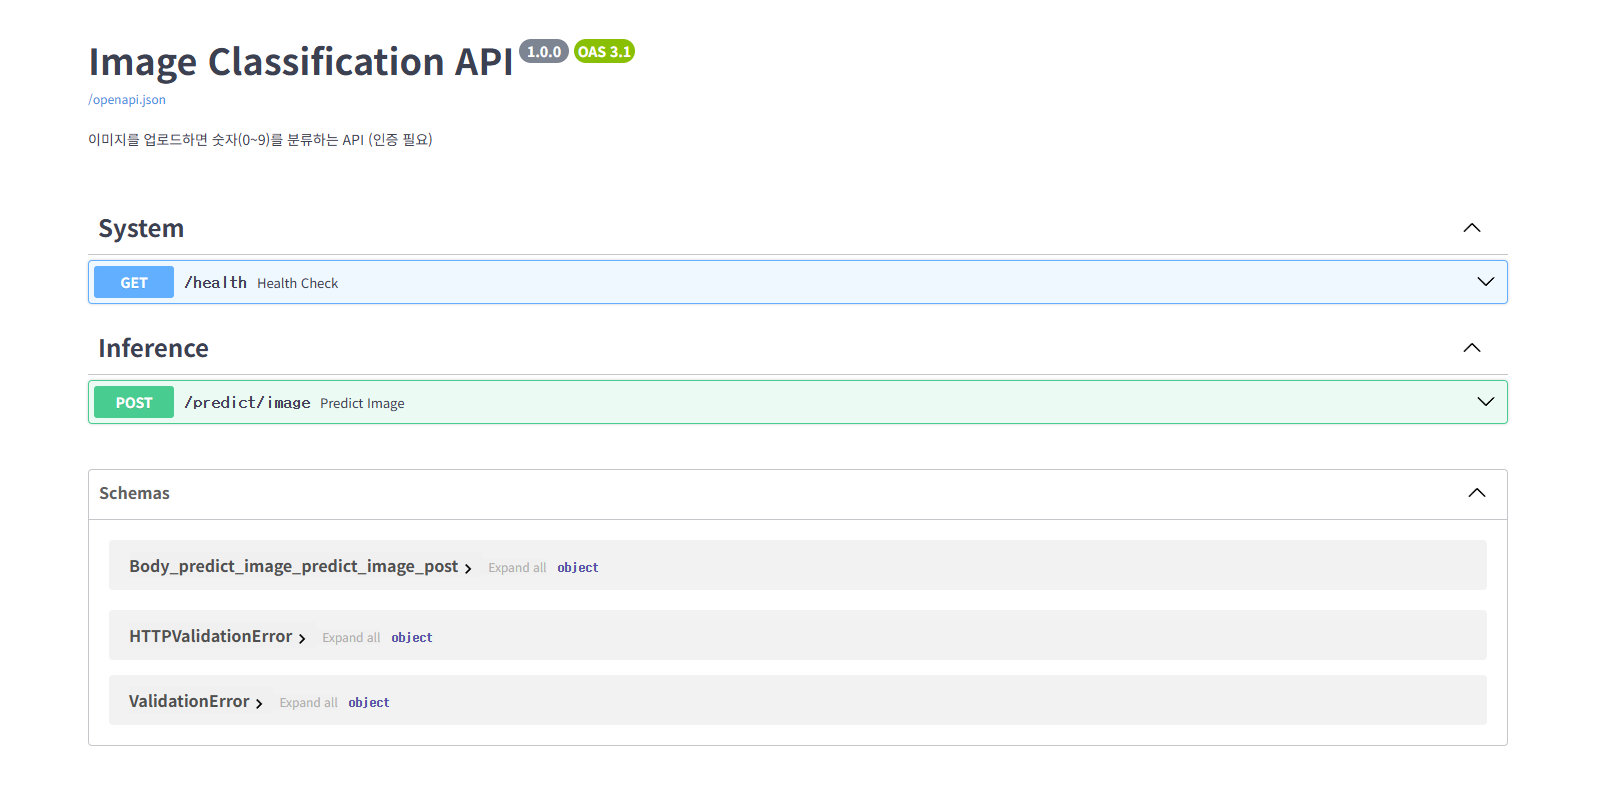

#### 2.2 연속된 추론 테스트(5장)
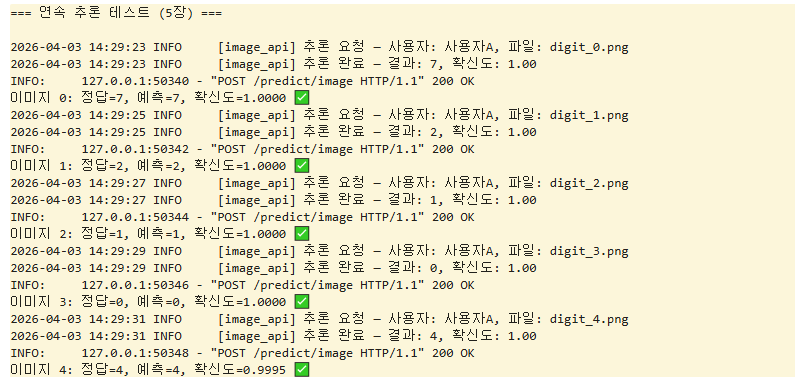

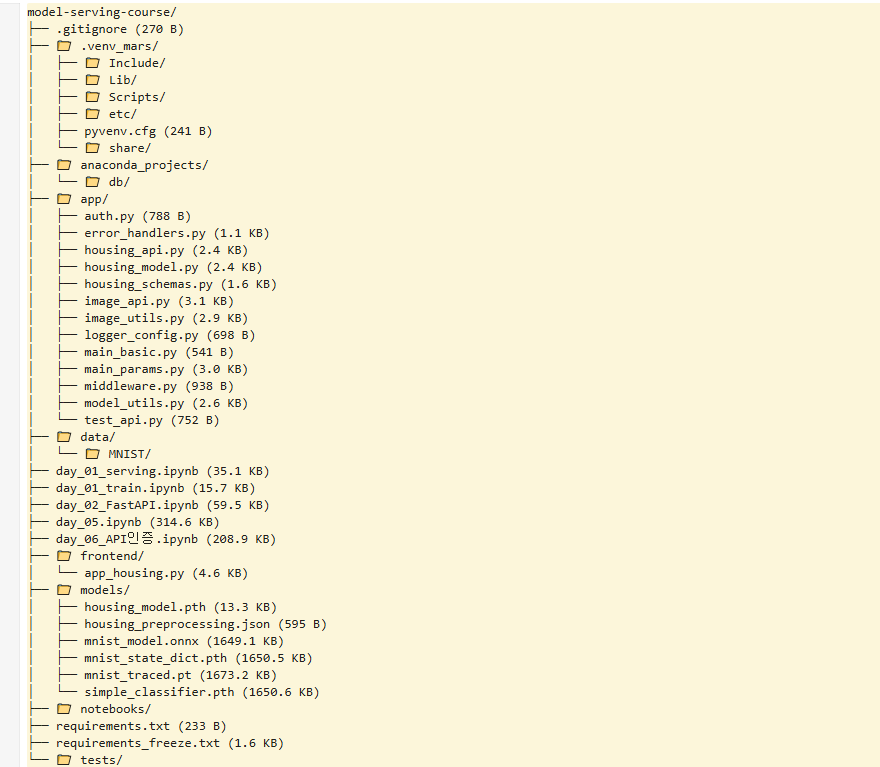
---

## 1. 폴더 확인 및 API key 인증 모듈

In [1]:
import os

print("현재 작업 폴더:", os.getcwd())

현재 작업 폴더: D:\PyProject\AIFFEL_AI\LLM\Deployment\Introduction\model-serving-course


In [3]:
os.makedirs("app", exist_ok=True)
os.makedirs("models", exist_ok=True)

print("app/, models/ 폴더 확인 완료")

app/, models/ 폴더 확인 완료


In [5]:
%%writefile app/auth.py
"""
Day 6 - API Key 인증 모듈
"""
from fastapi import Header, HTTPException

# 예시용 API Key 저장소
VALID_API_KEYS = {
    "test-key-001": "사용자A",
    "test-key-002": "사용자B",
}


async def verify_api_key(x_api_key: str = Header(None)) -> str:
    """
    X-API-Key 헤더를 검증하고, 인증된 사용자 이름을 반환합니다.
    """
    if x_api_key is None:
        raise HTTPException(
            status_code=401,
            detail="API Key가 필요합니다. X-API-Key 헤더를 포함해 주세요.",
        )

    if x_api_key not in VALID_API_KEYS:
        raise HTTPException(
            status_code=401,
            detail="유효하지 않은 API Key입니다.",
        )

    return VALID_API_KEYS[x_api_key]

Writing app/auth.py


In [7]:
from app.auth import verify_api_key
from fastapi import HTTPException

try:
    user = await verify_api_key(x_api_key="test-key-001")
    print(f"✅ 인증 성공: {user}")
except HTTPException as e:
    print(f"❌ 인증 실패: {e.detail}")

✅ 인증 성공: 사용자A


In [9]:
try:
    user = await verify_api_key(x_api_key="wrong-key")
    print(f"✅ 인증 성공: {user}")
except HTTPException as e:
    print(f"✅ 예상된 실패: {e.status_code} - {e.detail}")

✅ 예상된 실패: 401 - 유효하지 않은 API Key입니다.


In [11]:
try:
    user = await verify_api_key(x_api_key=None)
    print(f"✅ 인증 성공: {user}")
except HTTPException as e:
    print(f"✅ 예상된 실패: {e.status_code} - {e.detail}")

✅ 예상된 실패: 401 - API Key가 필요합니다. X-API-Key 헤더를 포함해 주세요.


In [13]:
try:
    user = await verify_api_key(x_api_key=None)
    print(f"✅ 인증 성공: {user}")
except HTTPException as e:
    print(f"✅ 예상된 실패: {e.status_code} - {e.detail}")

✅ 예상된 실패: 401 - API Key가 필요합니다. X-API-Key 헤더를 포함해 주세요.


## 2. 파일 업로드와 안전장치: 크기 제한, 이미지 리사이징
### 2.2 안전 장치 구현

In [1]:
%%writefile app/image_utils.py
"""
Day 6 - 이미지 업로드 안전장치 + 전처리
"""
from fastapi import UploadFile, HTTPException
from PIL import Image
import io

# 허용 설정
ALLOWED_TYPES = {"image/png", "image/jpeg", "image/jpg"}
MAX_FILE_SIZE = 5 * 1024 * 1024  # 5MB                     # *your code* — 최대 파일 크기


async def validate_and_read_image(
    file: UploadFile,
    max_size: int = MAX_FILE_SIZE,
    target_size: tuple = (28, 28),
) -> Image.Image:
    """
    업로드된 파일을 검증하고, PIL 이미지로 반환합니다.

    검증 순서:
      1. 파일 타입 검증 → 허용된 형식(PNG, JPEG)만 통과
      2. 파일 크기 검증 → 5MB 이하만 통과
      3. 이미지 디코딩 검증 → 실제로 열 수 있는 이미지만 통과
      4. 리사이징 + 그레이스케일 변환 → 모델 입력 크기에 맞춤
    """

    # ─── 1. 파일 타입 검증 ─────────────────────────
    # content_type은 클라이언트가 보낸 MIME 타입입니다.
    # .exe를 .png로 위장해도 content_type이 다르므로 차단됩니다.
    if file.content_type not in ALLOWED_TYPES:               # *your code* — 타입 체크
        raise HTTPException(
            status_code=400,
            detail=f"지원하지 않는 파일 형식입니다: {file.content_type}. "
                   f"허용 형식: {ALLOWED_TYPES}",
        )

    # ─── 2. 파일 크기 검증 ─────────────────────────
    # 파일 전체를 읽어서 크기를 확인합니다.
    # 이 시점에서 파일 내용이 메모리에 올라옵니다.
    contents = await file.read()
    if len(contents) > max_size:                             # *your code* — 크기 체크
        raise HTTPException(
            status_code=400,
            detail=f"파일 크기가 {max_size // (1024*1024)}MB를 초과합니다. "
                   f"현재: {len(contents) / (1024*1024):.1f}MB",
        )

    # ─── 3. 이미지 디코딩 검증 ─────────────────────
    # content_type이 image/png여도 파일 내용이 실제로 이미지가 아닐 수 있습니다.
    # PIL로 열어보면서 확인합니다.
    try:
        image = Image.open(io.BytesIO(contents))
    except Exception:
        raise HTTPException(
            status_code=400,
            detail="이미지를 읽을 수 없습니다. 파일이 손상되었을 수 있습니다.",
        )

    # ─── 4. 리사이징 + 그레이스케일 변환 ──────────────
    # 어떤 크기의 이미지가 들어와도 모델 입력에 맞게 변환합니다.
    image = image.convert("L").resize(target_size)           # *your code* — 그레이스케일 + 리사이즈

    return image

Writing app/image_utils.py


In [4]:
from PIL import Image
import io

# 테스트 이미지 생성 (28x28 그레이스케일)
test_img = Image.new("L", (100, 100), color=128)   # 100x100 회색 이미지
buffer = io.BytesIO()
test_img.save(buffer, format="PNG")
test_bytes = buffer.getvalue()

print(f"테스트 이미지 크기: {len(test_bytes)} bytes")
print(f"테스트 이미지 해상도: {test_img.size}")

테스트 이미지 크기: 120 bytes
테스트 이미지 해상도: (100, 100)


In [6]:
# 리사이징 테스트
img = Image.open(io.BytesIO(test_bytes))
img_resized = img.convert("L").resize((28, 28))
print(f"변환 전: {img.size} → 변환 후: {img_resized.size}")

변환 전: (100, 100) → 변환 후: (28, 28)


In [8]:
# 잘못된 파일 테스트
try:
    Image.open(io.BytesIO(b"this is not an image"))
except Exception as e:
    print(f"디코딩 실패: {type(e).__name__}")
# → 이런 경우 validate_and_read_image()가 400 에러를 반환합니다.

디코딩 실패: UnidentifiedImageError


## 사전 3. 추론 파이프라인: 전처리 → 모델 호출 → 후처리

---

> **학습 목표**
> - 이미지 업로드 → 전처리 → 모델 추론 → 결과 반환의 전체 파이프라인을 이해합니다.

---

### 사전 3.1 전체 파이프라인

```
[클라이언트]                              [서버]

POST /predict/image
Headers: X-API-Key: test-key-001     1. API Key 인증 (섹션 2)
Body: multipart/form-data            2. 파일 검증 + 리사이징 (섹션 4)
  └─ file: digit.png                 3. 텐서 변환 + 정규화
         ──────────────▶             4. 모델 추론 (run_in_executor)
                                     5. 후처리
         ◀──────────────             6. JSON 응답
{
  "predicted_class": "7",
  "confidence": 0.98
}
```

> 각 단계는 Day 1~5에서 배운 기술의 조합입니다.
> 새로운 것은 1번(인증)과 2번(파일 검증)뿐이고, 나머지는 이미 익숙한 패턴입니다.

---

## 3. 실습: 이미지를 업로드하면 분류 결과를 반환하는 API 만들기

---

> **실습 목표**
> - API Key 인증 + UploadFile + MNIST 모델을 결합한 API를 완성합니다.
> - Swagger UI에서 이미지를 업로드하여 추론 결과를 확인합니다.

---

### 3.1 통합 API 서버 코드

In [13]:
%%writefile app/image_api.py
"""
Day 6 - 이미지 분류 API (인증 + 파일 업로드 + MNIST 모델)
"""
import asyncio
from concurrent.futures import ThreadPoolExecutor

import torch
from fastapi import FastAPI, UploadFile, File, Depends, HTTPException
from torchvision import transforms

from app.model_utils import load_model, predict, CLASS_NAMES
from app.auth import verify_api_key
from app.image_utils import validate_and_read_image
from app.logger_config import setup_logger
from app.error_handlers import register_error_handlers
from app.middleware import RequestLoggingMiddleware


# ===== 설정 =====
logger = setup_logger("image_api")

app = FastAPI(
    title="Image Classification API",
    description="이미지를 업로드하면 숫자(0~9)를 분류하는 API (인증 필요)",
    version="1.0.0",
)

app.add_middleware(RequestLoggingMiddleware)
register_error_handlers(app)

executor = ThreadPoolExecutor(max_workers=4, thread_name_prefix="image")

# ===== 모델 로드 =====
MODEL_PATH = "models/mnist_state_dict.pth"
model = None

# 전처리 파이프라인 (PIL → Tensor)
img_transform = transforms.Compose([               # *your code* — transforms.Compose 구성
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])


@app.on_event("startup")
async def startup():
    global model
    logger.info("MNIST 모델 로드 중...")
    model = load_model(MODEL_PATH)
    logger.info("모델 로드 완료")


def run_inference(tensor: torch.Tensor) -> dict:
    if model is None:
        raise RuntimeError("모델이 로드되지 않았습니다")
    return predict(model, tensor)


# ===== 엔드포인트 =====

@app.get("/health", tags=["System"])
async def health_check():
    return {"status": "healthy" if model else "loading"}


@app.post("/predict/image", tags=["Inference"])
async def predict_image(
    file: UploadFile = File(..., description="분류할 이미지 (PNG, JPEG)"),
    user: str = Depends(verify_api_key),                     # *your code* — 인증 적용
):
    """
    이미지를 업로드하면 숫자(0~9)를 분류합니다.
    X-API-Key 헤더에 유효한 API Key가 필요합니다.
    """
    logger.info(f"추론 요청 — 사용자: {user}, 파일: {file.filename}")

    # 1. 파일 검증 + 이미지 로드 (28x28 그레이스케일로 변환)
    image = await validate_and_read_image(file, target_size=(28, 28))  # *your code* — 안전장치 적용

    # 2. 텐서 변환
    tensor = img_transform(image).unsqueeze(0)   # (1, 1, 28, 28)

    # 3. 비동기 추론
    try:
        loop = asyncio.get_event_loop()
        result = await loop.run_in_executor(executor, run_inference, tensor)
    except Exception as e:
        logger.error(f"추론 실패: {e}")
        raise HTTPException(status_code=500, detail=f"추론 실패: {str(e)}")

    logger.info(f"추론 완료 — 결과: {result['predicted_class']}, 확신도: {result['confidence']:.2f}")

    return {
        "success": True,
        "predicted_class": result["predicted_class"],
        "confidence": round(result["confidence"], 4),
        "user": user,
    }

Writing app/image_api.py


---

### 3.2 서버 실행

In [1]:
import nest_asyncio, uvicorn, threading, time

nest_asyncio.apply()

def run_server():
    uvicorn.run("app.image_api:app", host="0.0.0.0", port=8000)

server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()
time.sleep(3)
print("✅ 서버 시작됨 — http://localhost:8000/docs 에서 Swagger UI를 확인하세요.")

✅ 서버 시작됨 — http://localhost:8000/docs 에서 Swagger UI를 확인하세요.


In [3]:
## 헬스 체크
import requests

response = requests.get("http://localhost:8000/health")
print("상태 코드:", response.status_code)
print("응답:", response.json())

INFO:     127.0.0.1:50260 - "GET /health HTTP/1.1" 200 OK
상태 코드: 200
응답: {'status': 'healthy'}


---

### 3.3 테스트 1: 인증 없이 요청 → 401

In [ ]:
import requests

# API Key 없이 요청
response = requests.post(
    "http://localhost:8000/predict/image",
    files={"file": ("test.png", b"fake image data", "image/png")},
    # headers 없음 → 인증 실패
)

print(f"상태 코드: {response.status_code}")   # 401
print(f"응답: {response.json()}")

---

### 3.4 테스트 2: 잘못된 키 → 401

In [7]:
response = requests.post(
    "http://localhost:8000/predict/image",
    files={"file": ("test.png", b"fake image data", "image/png")},
    headers={"X-API-Key": "wrong-key"},                      # *your code* — 잘못된 키
)

print(f"상태 코드: {response.status_code}")   # 401
print(f"응답: {response.json()}")

POST /predict/image → 401 (0.002s)


INFO:     127.0.0.1:50276 - "POST /predict/image HTTP/1.1" 401 Unauthorized
상태 코드: 401
응답: {'detail': '유효하지 않은 API Key입니다.'}


---

### 3.5 테스트 3: 올바른 키 + MNIST 이미지 → 성공
- MNIST 테스트 이미지 1장으로 정상 추론

In [10]:
from torchvision import datasets
from PIL import Image
import io

# MNIST 테스트 이미지 가져오기
test_dataset = datasets.MNIST(root="data", train=False, download=True)
test_image, test_label = test_dataset[0]   # 첫 번째 테스트 이미지

# PIL 이미지 → bytes 변환
buf = io.BytesIO()
test_image.save(buf, format="PNG")
image_bytes = buf.getvalue()

print(f"테스트 이미지 정답: {test_label}")

# API 호출
response = requests.post(
    "http://localhost:8000/predict/image",
    files={"file": ("digit.png", image_bytes, "image/png")},
    headers={"X-API-Key": "test-key-001"},                   # *your code* — 올바른 키
)

print(f"상태 코드: {response.status_code}")   # 200
result = response.json()
print(f"예측 결과: {result}")

테스트 이미지 정답: 7
2026-04-03 14:27:16 INFO     [image_api] 추론 요청 — 사용자: 사용자A, 파일: digit.png
2026-04-03 14:27:16 INFO     [image_api] 추론 완료 — 결과: 7, 확신도: 1.00
INFO:     127.0.0.1:50301 - "POST /predict/image HTTP/1.1" 200 OK
상태 코드: 200
예측 결과: {'success': True, 'predicted_class': '7', 'confidence': 1.0, 'user': '사용자A'}


---

### 6.6 테스트 4: 잘못된 파일 형식 → 400
- 잘못된 파일 형식 테스트

In [13]:
response = requests.post(
    "http://localhost:8000/predict/image",
    files={"file": ("test.txt", b"this is not an image", "text/plain")},
    headers={"X-API-Key": "test-key-001"},
)

print(f"상태 코드: {response.status_code}")   # 400
print(f"응답: {response.json()}")

2026-04-03 14:28:32 INFO     [image_api] 추론 요청 — 사용자: 사용자A, 파일: test.txt


POST /predict/image → 400 (0.001s)


INFO:     127.0.0.1:50313 - "POST /predict/image HTTP/1.1" 400 Bad Request
상태 코드: 400
응답: {'detail': "지원하지 않는 파일 형식입니다: text/plain. 허용 형식: {'image/png', 'image/jpg', 'image/jpeg'}"}


---

### 3.7 테스트 5: 여러 이미지 연속 테스트
- 연속 추론 테스트 5장

In [16]:
import requests
from torchvision import datasets
import io

test_dataset = datasets.MNIST(root="data", train=False, download=True)

print("=== 연속 추론 테스트 (5장) ===\n")

for i in range(5):
    img, label = test_dataset[i]

    buf = io.BytesIO()
    img.save(buf, format="PNG")

    resp = requests.post(
        "http://localhost:8000/predict/image",
        files={"file": (f"digit_{i}.png", buf.getvalue(), "image/png")},
        headers={"X-API-Key": "test-key-001"},
    )

    r = resp.json()
    predicted = r.get("predicted_class", "?")
    confidence = r.get("confidence", 0)
    match = "✅" if str(label) == str(predicted) else "❌"

    print(f"이미지 {i}: 정답={label}, 예측={predicted}, 확신도={confidence:.4f} {match}")

=== 연속 추론 테스트 (5장) ===

2026-04-03 14:29:23 INFO     [image_api] 추론 요청 — 사용자: 사용자A, 파일: digit_0.png
2026-04-03 14:29:23 INFO     [image_api] 추론 완료 — 결과: 7, 확신도: 1.00
INFO:     127.0.0.1:50340 - "POST /predict/image HTTP/1.1" 200 OK
이미지 0: 정답=7, 예측=7, 확신도=1.0000 ✅
2026-04-03 14:29:25 INFO     [image_api] 추론 요청 — 사용자: 사용자A, 파일: digit_1.png
2026-04-03 14:29:25 INFO     [image_api] 추론 완료 — 결과: 2, 확신도: 1.00
INFO:     127.0.0.1:50342 - "POST /predict/image HTTP/1.1" 200 OK
이미지 1: 정답=2, 예측=2, 확신도=1.0000 ✅
2026-04-03 14:29:27 INFO     [image_api] 추론 요청 — 사용자: 사용자A, 파일: digit_2.png
2026-04-03 14:29:27 INFO     [image_api] 추론 완료 — 결과: 1, 확신도: 1.00
INFO:     127.0.0.1:50344 - "POST /predict/image HTTP/1.1" 200 OK
이미지 2: 정답=1, 예측=1, 확신도=1.0000 ✅
2026-04-03 14:29:29 INFO     [image_api] 추론 요청 — 사용자: 사용자A, 파일: digit_3.png
2026-04-03 14:29:29 INFO     [image_api] 추론 완료 — 결과: 0, 확신도: 1.00
INFO:     127.0.0.1:50346 - "POST /predict/image HTTP/1.1" 200 OK
이미지 3: 정답=0, 예측=0, 확신도=1.0000 ✅
2026-04-03 14:29

In [18]:
print("브라우저에서 아래 주소로 접속하세요.")
print("http://localhost:8000/docs")
print()
print("POST /predict/image 에서 Try it out 클릭")
print("x_api_key 에 test-key-001 입력")
print("파일 선택 후 Execute")

브라우저에서 아래 주소로 접속하세요.
http://localhost:8000/docs

POST /predict/image 에서 Try it out 클릭
x_api_key 에 test-key-001 입력
파일 선택 후 Execute


In [27]:
import os

def show_tree(path, prefix="", max_depth=2, current_depth=0):
    """프로젝트 폴더 구조를 트리 형태로 출력합니다."""
    if current_depth >= max_depth:
        return

    entries = sorted(os.listdir(path))
    # .venv 등 무거운 폴더는 제외
    entries = [e for e in entries if e not in {".venv", ".venv_test", "__pycache__", ".ipynb_checkpoints"}]

    for i, entry in enumerate(entries):
        full_path = os.path.join(path, entry)
        connector = "└── " if i == len(entries) - 1 else "├── "

        if os.path.isdir(full_path):
            print(f"{prefix}{connector}📁 {entry}/")
            extension = "    " if i == len(entries) - 1 else "│   "
            show_tree(full_path, prefix + extension, max_depth, current_depth + 1)
        else:
            size = os.path.getsize(full_path)
            if size > 1024:
                size_str = f"({size/1024:.1f} KB)"
            else:
                size_str = f"({size} B)"
            print(f"{prefix}{connector}{entry} {size_str}")

print("model-serving-course/")
show_tree(".")

model-serving-course/
├── .gitignore (270 B)
├── 📁 .venv_mars/
│   ├── 📁 Include/
│   ├── 📁 Lib/
│   ├── 📁 Scripts/
│   ├── 📁 etc/
│   ├── pyvenv.cfg (241 B)
│   └── 📁 share/
├── 📁 anaconda_projects/
│   └── 📁 db/
├── 📁 app/
│   ├── auth.py (788 B)
│   ├── error_handlers.py (1.1 KB)
│   ├── housing_api.py (2.4 KB)
│   ├── housing_model.py (2.4 KB)
│   ├── housing_schemas.py (1.6 KB)
│   ├── image_api.py (3.1 KB)
│   ├── image_utils.py (2.9 KB)
│   ├── logger_config.py (698 B)
│   ├── main_basic.py (541 B)
│   ├── main_params.py (3.0 KB)
│   ├── middleware.py (938 B)
│   ├── model_utils.py (2.6 KB)
│   └── test_api.py (752 B)
├── 📁 data/
│   └── 📁 MNIST/
├── day_01_serving.ipynb (35.1 KB)
├── day_01_train.ipynb (15.7 KB)
├── day_02_FastAPI.ipynb (59.5 KB)
├── day_05.ipynb (314.6 KB)
├── day_06_API인증.ipynb (208.9 KB)
├── 📁 frontend/
│   └── app_housing.py (4.6 KB)
├── 📁 models/
│   ├── housing_model.pth (13.3 KB)
│   ├── housing_preprocessing.json (595 B)
│   ├── mnist_model.onnx (1649.1